## Oppgave 1 a)

In [ ]:
import pandas as pd

df = pd.read_csv('Boligpris.csv', sep=';', decimal=',')

snitt_alle = df['Pris'].mean()
df_sortert_pris = df.sort_values('Pris', ascending=False)
df_sortert_pris_10 = df_sortert_pris.head(10)
snitt_10 = df_sortert_pris['Pris'].head(10).mean()

print(f'Gjennomsnittlig salgpsris er {snitt_alle:.2f} kr')
print('De 10 dyreste boligene er:')
display(df_sortert_pris_10)
print(f'Gjennomsnittsprisen til disse 10 er {snitt_10:.2f} kr')

Gjennomsnittlig salgpsris er 3691700.35 kr
De 10 dyreste boligene er:


,Pris,Areal,Tilstand,Alder,Sentrum,Sol
41,7218513,267.9,8,1.0,2.30,17.1
156,6912001,269.1,6,0.6,2.28,19.7
193,6778836,246.6,7,1.0,3.75,13.5
44,6707701,224.3,9,10.4,3.32,13.8
194,6612465,248.6,2,1.0,3.73,12.5
64,6571278,244.1,1,2.8,0.67,17.3
30,6367171,196.6,9,5.9,2.64,19.3
143,6253702,245.8,9,8.7,0.26,13.5
15,6169432,241.8,10,11.0,0.60,17.1
192,6157293,218.2,10,21.0,0.06,19.9


Gjennomsnittsprisen til disse 10 er 6574839.20 kr


## Oppgave 1 b)

Det virker å være en positiv samvariasjon mellom pris og areal.
I gjennomsnitt øker prisen hvis arealet øker.


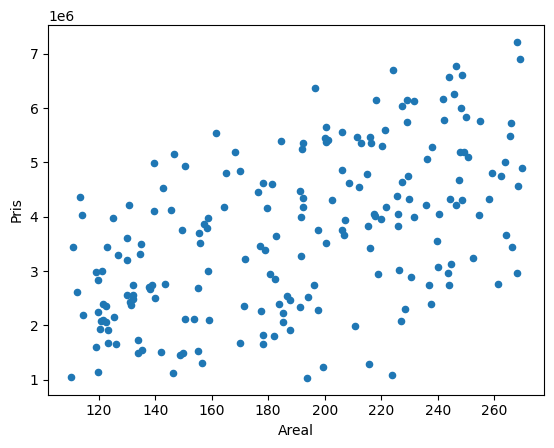

In [2]:
df.plot(x='Areal', y='Pris', kind='scatter')
print('Det virker å være en positiv samvariasjon mellom pris og areal.')
print('I gjennomsnitt øker prisen hvis arealet øker.')

Det virker å være en negativ samvariasjon mellom pris og areal.
I gjennomsnitt synker prisen hvis alderen øker.


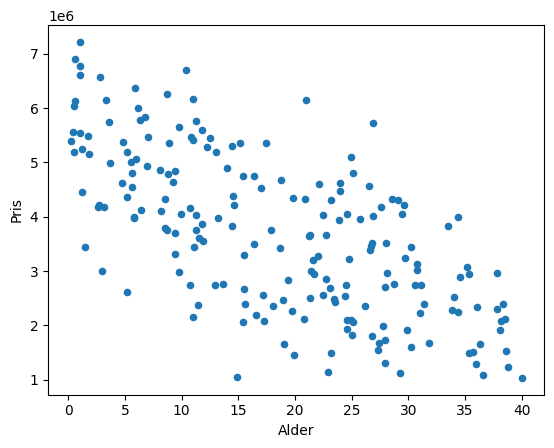

In [3]:
df.plot(x='Alder', y='Pris', kind='scatter')
print('Det virker å være en negativ samvariasjon mellom pris og areal.')
print('I gjennomsnitt synker prisen hvis alderen øker.')

## Oppgave 2 a)

In [4]:
df['Tilstandsgrad'] = pd.cut(df['Tilstand'],
                      bins=[0, 3, 6, 8, 10],
                      labels=['Dårlig', 'Middels', 'God', 'Utmerket'])

df.groupby('Tilstandsgrad')[['Pris']].mean().astype(int)

,Pris
Tilstandsgrad,
Dårlig,3324348
Middels,3540629
God,3927487
Utmerket,4293785


## Oppgave 2 b)

In [5]:
df['Solforhold'] = pd.cut(df['Sol'],
                   bins=[0, 14, 16, 18, 24],
                   labels=['Dårlig', 'Middels', 'God', 'Utmerket'])

krysstabell = pd.crosstab(df['Tilstandsgrad'], df['Solforhold'], margins=True)
display(krysstabell)

antall_uu = krysstabell.loc['Utmerket', 'Utmerket']
print(f'Det er {antall_uu} boliger som er utmerket i begge kategoriene.')

Solforhold,Dårlig,Middels,God,Utmerket,All
Tilstandsgrad,,,,,
Dårlig,16,11,14,18,59
Middels,15,14,15,20,64
God,8,12,12,9,41
Utmerket,9,8,7,12,36
All,48,45,48,59,200


Det er 12 boliger som er utmerket i begge kategoriene.


## Oppgave 3

In [6]:
df['Areal'] = df['Areal'].round().astype(int)
df['Pris kvm'] = (df['Pris'] / df['Areal']).round(2)

df.pivot_table(values='Pris kvm', 
               index='Tilstandsgrad', 
               columns='Solforhold', 
               aggfunc='mean').round().astype(int)

Solforhold,Dårlig,Middels,God,Utmerket
Tilstandsgrad,,,,
Dårlig,17947,15090,16697,16348
Middels,17749,23116,20326,16871
God,19066,23393,24587,20001
Utmerket,22350,18595,23410,24661
